In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_climb(holds: np.ndarray, roles: np.ndarray, filename=None, title="Generated Climb"):
    """
    Visualizes a single static climb based on the 6-float encoding and a roles array.
    
    Args:
        holds (np.ndarray): Array of shape (S, 6) representing 
                            [x, y, pull_x, pull_y, pull_value, is_foot].
        roles (np.ndarray): Array of shape (S,) with integers representing hold roles:
                            0=start, 1=finish, 2=hand, 3=foot.
        filename (str): Output filename for the image.
        title (str): Title of the plot.
    """
    # Setup the figure and axis
    fig, ax = plt.subplots(figsize=(6, 8))
    
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel("X Position (Normalized)")
    ax.set_ylabel("Y Position (Normalized)")
    ax.set_title(title)
    
    # Unpack the 6-float encoding (ignoring the 6th float since we now use 'roles')
    x = holds[:, 0]
    y = holds[:, 1]
    pull_x = holds[:, 2]
    pull_y = holds[:, 3]
    pull_value = holds[:, 4]

    # Create boolean masks for each role
    is_start = roles == 0
    is_finish = roles == 1
    is_hand = roles == 2
    is_foot = roles == 3
    
    # Plot Scatter points by role (Positions, Sizes, Colors mapped to pull_value)
    
    # 0 = Start Holds (Squares)
    if np.any(is_start):
        ax.scatter(x[is_start], y[is_start], c=pull_value[is_start], s=80, 
                   cmap='viridis', vmin=0.2, vmax=1, zorder=3, marker='s', edgecolors='black')

    # 1 = Finish Holds (Stars)
    if np.any(is_finish):
        ax.scatter(x[is_finish], y[is_finish], c=pull_value[is_finish], s=150, 
                   cmap='viridis', vmin=0.2, vmax=1, zorder=3, marker='*', edgecolors='black')

    # 2 = Handholds (Circles)
    if np.any(is_hand):
        ax.scatter(x[is_hand], y[is_hand], c=pull_value[is_hand], s=50, 
                   cmap='viridis', vmin=0.2, vmax=1, zorder=2, marker='o')
                   
    # 3 = Footholds (Crosses)
    if np.any(is_foot):
        ax.scatter(x[is_foot], y[is_foot], c=pull_value[is_foot], s=20, 
                   cmap='viridis', vmin=0.2, vmax=1, zorder=2, marker='x')
    
    # Add a standalone colorbar (safer when splitting scatter plots conditionally)
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0.2, vmax=1))
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Pull Value (Strength)')
    
    # Plot Quiver for pull vectors (plots all arrows at once)
    ax.quiver(x, y, pull_x * 0.2 * pull_value, pull_y * 0.2 * pull_value, 
              color='green', alpha=0.6,
              angles='xy', scale_units='xy', scale=0.5,
              width=0.005, headwidth=3, zorder=1)
    
    # Save and display
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=300)
        print(f"Climb plot saved to {filename}")
    plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def animate_climb_generation(guesses: list, filename="climb_diffusion_no_projection.gif", title="Diffusion Process, V4 @45*, No Projection", fps=15):
    """
    Creates a GIF animating the DDPM denoising process.
    
    Args:
        guesses (list): A list of numpy arrays. Each array should be shape (N, 6) 
                        representing [x, y, pull_x, pull_y, pull_value, is_foot] at a specific timestep.
        filename (str): Output filename for the GIF.
        fps (int): Frames per second.
    """
    n_holds = len(guesses[0])
    # Setup the figure and axis
    fig, ax = plt.subplots(figsize=(6, 8))
    
    # We set limits slightly wider than the standard -1,1 to see the noise coalescing
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel("X Position (Normalized)")
    ax.set_ylabel("Y Position (Normalized)")
    
    # Initialize graphic elements
    # Using vmin=0, vmax=1 maps perfectly to your new pull_value range!
    dummy = np.zeros(n_holds)
    scat = ax.scatter(dummy, dummy, c=dummy, s=dummy, cmap='viridis', vmin=0, vmax=1, zorder=2)
    
    # Quiver plot for pull vectors
    quiv = ax.quiver(dummy, dummy, dummy, dummy, 
                     color='green', alpha=0.6,
                     angles='xy', scale_units='xy', scale=0.5,
                     width=0.005, headwidth=3, zorder=1)

    def init():
        """Initialize empty data for the animation."""
        scat.set_offsets(np.empty((0, 2)))
        quiv.set_offsets(np.empty((0, 2)))
        quiv.set_UVC(dummy, dummy)
        return scat, quiv

    def update(frame_idx):
        """Update function for each frame of the animation."""
        # Get data for the current timestep
        data = guesses[frame_idx]
        
        # Unpack the new 6-float encoding
        x = data[:, 0]
        y = data[:, 1]
        pull_x = data[:, 2]
        pull_y = data[:, 3]
        pull_value = data[:, 4]
        is_foot_flag = data[:, 5]

        # Determine which holds act as "hands" vs "feet" using the new flag
        # If is_foot > 0 implies foothold, then <= 0 implies handhold
        is_hand = is_foot_flag <= 0
        
        # Calculate sizes based on type (Feet = 20, Hands = 50)
        sizes = np.full(len(is_hand), 20) + np.full(len(is_hand), 30) * is_hand.astype(float)
        
        # Update Scatter (Positions, Sizes, Colors)
        scat.set_offsets(np.c_[x, y])
        scat.set_sizes(sizes)
        # Use pull_value for the color mapping to visualize hold strength
        scat.set_array(pull_value) 
        
        # Update Quiver (Positions and Vectors)
        quiv.set_offsets(np.c_[x, y])
        # Note: Depending on how you generate pull_x/y, you may want to multiply by pull_value here
        quiv.set_UVC(pull_x * 0.2, pull_y * 0.2)
        
        # Update Title
        ax.set_title(f"{title}\n t={len(guesses)-frame_idx}/{len(guesses)}")
        
        return scat, quiv

    # Create the animation
    print(f"Generating animation with {len(guesses)} frames...")
    anim = FuncAnimation(fig, update, frames=len(guesses), init_func=init, blit=False)
    
    # Save to GIF
    writer = PillowWriter(fps=fps)
    anim.save(filename, writer=writer)
    print(f"Animation saved to {filename}")

c:\Users\EvanM\anaconda3\envs\torch-cpu\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([0, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1])

array([[-0.5 , -0.53,  0.  , -1.  ,  0.79, -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [ 0.72,  0.02,  0.01, -1.  ,  0.55,  1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [-0.39, -0.97, -0.71, -0.71,  0.61,  1.01, -1.  , -1.  , -1.  , -1.  , -1.  ],
       [ 0.12, -0.38,  0.  , -1.  ,  0.63, -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [-0.7 , -0.99,  0.76, -0.66,  0.55,  1.01, -1.  , -1.  , -1.  , -1.  , -1.  ],
       [-0.07,  0.06,  0.79, -0.62,  0.57, -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [-0.02,  0.13,  0.  , -1.  ,  0.66, -1.01, -1.  , -1.  , -1.  , -1.  , -1.  ],
       [ 0.39,  0.62,  0.61, -0.8 ,  0.59, -1.  , -1.  , -1.  , -1.  , -1.01, -1.  ],
       [-0.45, -0.21, -0.79, -0.62,  0.75, -1.01, -1.01, -1.  , -1.  , -1.01, -1.  ],
       [-0.29, -0.04,  0.6 , -0.81,  0.6 , -1.  , -1.  , -1.  , -1.  , -1.01, -0.99],
       [ 0.1 ,  0.36, -0.69, -0.72,  0.48, -1.  , -1.01, -1.01, -1.  ,  1.  , -1.  ],
       [-0.39, -0.04,  0.01, -1.  ,  0.75, -1.  , -1. 

array([[-0.61, -0.5 ,  0.  , -1.  ,  0.69, -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [ 0.65,  0.01,  0.  , -1.  ,  0.52,  1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [-0.52, -0.87, -0.69, -0.73,  0.63,  1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [ 0.17, -0.4 ,  0.  , -1.  ,  0.61, -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [-0.69, -0.87,  0.76, -0.64,  0.63,  1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [-0.3 ,  0.11,  0.81, -0.59,  0.54, -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [-0.09,  0.15,  0.  , -1.  ,  0.68, -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [ 0.35,  0.62,  0.71, -0.71,  0.5 , -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [-0.43, -0.22, -0.71, -0.7 ,  0.66, -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [-0.26, -0.12,  0.64, -0.77,  0.55, -1.  , -1.  , -1.  , -1.  , -1.  , -1.  ],
       [ 0.09,  0.43, -0.69, -0.72,  0.5 , -1.  , -1.  , -1.  , -1.  ,  1.  , -1.  ],
       [-0.35, -0.12,  0.  , -1.  ,  0.65, -1.  , -1. 

tensor(14.4993)

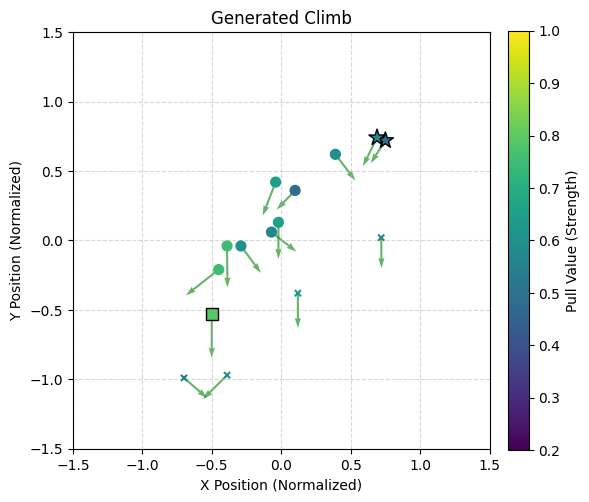

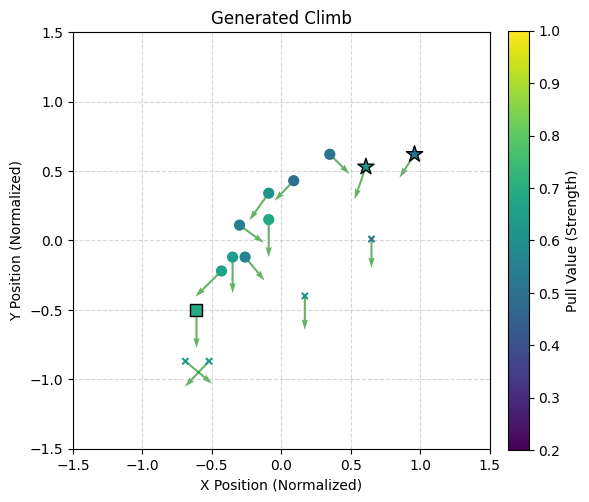

In [50]:
"""
DDPM model classes and generator for climb generation.

Ported from model-training/unet_diffusion.py and model-training/climb_conversion.py.
Contains:
- Noiser (U-Net style denoiser with role conditioning and CFG)
- ClimbDDPM (diffusion wrapper with predict_cfg)
- ClimbsFeatureScaler (data normalization — 11-dim hold features)
- ClimbDDPMGenerator (generation with manifold projection)
"""
import json
import math
import numpy as np
np.set_printoptions(linewidth=150)
import pandas as pd
import sqlite3
import joblib
import os
from pathlib import Path

import torch
import torch.nn as nn
from torch import Tensor
from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

DB_PATH = "data/storage.db"
SCALER_WEIGHTS_PATH = 'data/weights/scaler-weights.joblib'
DDPM_WEIGHTS_PATH = 'data/weights/ddpm-weights.pth'
LAYOUT_ID = 'layout-f311591b6b8b'

STYLE_TAGS = ["sloper", "pinch", "macro", "flat", "jug"]
BINARY_FEATURES = ["is_foot"] + STYLE_TAGS
SCALED_FEATURES = ["x", "y", "pull_x", "pull_y"]
HOLD_FEATURE_COLS = SCALED_FEATURES + ["useability"] + BINARY_FEATURES  # 11-dim
NUM_HOLD_FEATURES = len(HOLD_FEATURE_COLS) 
FEATURE_WEIGHTS = [1.0,1.0,0.5,0.5,0.5,0.3,0.01,0.01,0.01,0.01,0.01]

ROLE_START  = 0
ROLE_FINISH = 1
ROLE_HAND   = 2
ROLE_FOOT   = 3
ROLE_NULL   = 4
NUM_ROLES   = 5
SEQ_LEN     = 20

# ---------------------------------------------------------------------------
# Neural network building blocks
# ---------------------------------------------------------------------------

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim, padding=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=padding)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=padding)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act = nn.SiLU()
        self.cond_proj = nn.Linear(cond_dim, out_channels * 2)
        self.shortcut = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x, cond):
        h = self.conv1(x)
        h = self.norm1(h)
        gamma, beta = self.cond_proj(cond).unsqueeze(-1).chunk(2, dim=1)
        h = h * (1 + gamma) + beta
        h = self.act(h)
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)
        return h + self.shortcut(x)


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim: int = 128):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, 0].unsqueeze(1) * embeddings.unsqueeze(0)
        return torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)


# ---------------------------------------------------------------------------
# Noiser (U-Net denoiser with role conditioning and CFG)
# ---------------------------------------------------------------------------

class Noiser(nn.Module):
    """
    U-Net denoiser with concatenation skip connections, role conditioning,
    and classifier-free guidance support via learned null embeddings.

    Input:  (B, S, in_feature_dim)  — hold features concatenated with role one-hot
    Output: (B, S, out_feature_dim) — predicted noise for hold features only
    """
    def __init__(
        self,
        hidden_dim: int = 256,
        n_layers: int = 3,
        in_feature_dim: int = 16,   # NUM_HOLD_FEATURES + NUM_ROLES = 11 + 5
        out_feature_dim: int = 11,  # NUM_HOLD_FEATURES
        cond_dim: int = 4,
        sinusoidal: bool = True,
    ):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim) if sinusoidal else nn.Linear(1, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # Learnable null embeddings for CFG
        self.null_cond_emb = nn.Parameter(torch.randn(1, hidden_dim))
        self.null_roles = torch.full((1, SEQ_LEN, NUM_ROLES), -1.0, dtype=torch.float32)

        self.combine_t_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.init_conv = ResidualBlock1D(in_feature_dim, hidden_dim, hidden_dim)
        self.down_blocks = nn.ModuleList(
            [ResidualBlock1D(hidden_dim * (i + 1), hidden_dim * (i + 2), hidden_dim) for i in range(n_layers)]
        )
        self.bottom_block = ResidualBlock1D(hidden_dim * (n_layers + 1), hidden_dim * n_layers, hidden_dim)
        self.up_blocks = nn.ModuleList(
            [ResidualBlock1D(hidden_dim * i * 2, hidden_dim * (i - 1), hidden_dim) for i in range(n_layers, 1, -1)]
        )
        self.top_block = ResidualBlock1D(hidden_dim * 2, hidden_dim, hidden_dim)
        self.head = nn.Conv1d(hidden_dim, out_feature_dim, 1)

    def forward(
        self,
        climbs: Tensor,
        roles: Tensor | None,
        cond: Tensor | None,
        t: Tensor,
        role_mask: Tensor | None = None,
        cond_mask: Tensor | None = None,
    ) -> Tensor:
        B, S, H = climbs.shape
        emb_t = self.time_mlp(t)

        # Roles handling
        null_r = self.null_roles.to(climbs.device).expand(B, -1, -1)
        if roles is None:
            roles = null_r
        elif role_mask is not None:
            roles = torch.where(role_mask.view(B, 1, 1), null_r, roles)

        h = torch.cat([climbs, roles], dim=2)

        # Cond handling
        if cond is None:
            emb_c = self.null_cond_emb.to(climbs.device).expand(B, -1)
        else:
            emb_c = self.cond_mlp(cond)
            if cond_mask is not None:
                null_c = self.null_cond_emb.to(climbs.device).expand(B, -1)
                emb_c = torch.where(cond_mask.view(B, 1), null_c, emb_c)

        emb_c = self.combine_t_mlp(torch.cat([emb_t, emb_c], dim=1))
        emb_h = self.init_conv(h.transpose(1, 2), emb_c)

        residuals = []
        for layer in self.down_blocks:
            residuals.append(emb_h)
            emb_h = layer(emb_h, emb_c)

        emb_h = self.bottom_block(emb_h, emb_c)

        for layer in self.up_blocks:
            residual = residuals.pop()
            emb_h = layer(torch.cat([emb_h, residual], dim=1), emb_c)

        residual = residuals.pop()
        emb_h = self.top_block(torch.cat([emb_h, residual], dim=1), emb_c)

        return self.head(emb_h).transpose(1, 2)


# ---------------------------------------------------------------------------
# ClimbDDPM (diffusion process with CFG)
# ---------------------------------------------------------------------------

class ClimbDDPM(nn.Module):
    def __init__(self, model: nn.Module, weights_path: Path | str | None = None):
        super().__init__()
        self.model = model
        if weights_path:
            self.load_state_dict(clear_compile_keys(weights_path))

    def _cos_alpha_bar(self, t: Tensor) -> Tensor:
        t = t.view(-1, 1, 1)
        epsilon = 0.0004
        return torch.cos((t + epsilon) / (1 + 2 * epsilon) * torch.pi / 2) ** 2

    def predict_clean(self, noisy, roles, cond, t) -> Tensor:
        a = self._cos_alpha_bar(t)
        prediction = self.model(noisy, roles, cond, t)
        return (noisy - torch.sqrt(1 - a) * prediction) / torch.sqrt(a)

    def predict_cfg(self, noisy, roles, cond, t, guidance_value: float = 3.0) -> Tensor:
        """Classifier-free guidance prediction."""
        a = self._cos_alpha_bar(t)
        cf_pred = self.model(noisy, None, None, t)
        pred = self.model(noisy, roles, cond, t)
        cfg = cf_pred + (pred - cf_pred) * guidance_value
        return (noisy - torch.sqrt(1 - a) * cfg) / torch.sqrt(a)

    def forward_diffusion(self, clean: Tensor, t: Tensor, noise: Tensor) -> Tensor:
        a = self._cos_alpha_bar(t)
        return torch.sqrt(a) * clean + torch.sqrt(1 - a) * noise

    def forward(self, noisy, roles, cond, t):
        return self.predict_clean(noisy, roles, cond, t)


# ---------------------------------------------------------------------------
# Feature scaler (11-dim hold features with style tags)
# ---------------------------------------------------------------------------

class ClimbsFeatureScaler:
    """Handles normalization of climb conditional features and hold features.

    Hold features: x, y, pull_x, pull_y (scaled), useability (raw),
                   is_foot + 5 style tags (binary mapped to [-1, 1]).
    """

    def __init__(self, weights_path: Path | str | None = None):
        self.cond_features_scaler = MinMaxScaler(feature_range=(-1, 1))
        self.hold_position_scaler = MinMaxScaler(feature_range=(-1, 1))
        if weights_path and os.path.exists(weights_path):
            self.load_weights(weights_path)

    def save_weights(self, path: str):
        state = {
            "cond_scaler": self.cond_features_scaler,
            "hold_position_scaler": self.hold_position_scaler,
        }
        joblib.dump(state, path)

    def load_weights(self, path: Path | str):
        state = joblib.load(path)
        self.cond_features_scaler = state["cond_scaler"]
        self.hold_position_scaler = state["hold_position_scaler"]

    def _apply_hold_transforms(self, dfh: pd.DataFrame) -> pd.DataFrame:
        """Parse style tags from JSON, create binary columns, and map binary
        features (is_foot + style tags) from {0, 1} → {-1, 1}."""
        dfh = dfh.copy()
        for tag in STYLE_TAGS:
            dfh[tag] = dfh["tags"].apply(
                lambda t: 1.0 if isinstance(t, str) and tag in json.loads(t) else 0.0
            )
        for col in BINARY_FEATURES:
            dfh[col] = dfh[col].astype(float) * 2 - 1
        if "tags" in dfh.columns:
            dfh = dfh.drop(columns=["tags"])
        return dfh

    def _apply_log_transforms(self, dfc: pd.DataFrame) -> pd.DataFrame:
        dfc = dfc.copy()
        dfc["quality"] -= 3
        dfc["quality"] = np.log(1 - dfc["quality"])
        dfc["ascents"] = np.log(dfc["ascents"])
        return dfc

    def transform_climb_features(self, climbs_to_transform: pd.DataFrame, to_df: bool = False):
        dfc = climbs_to_transform.copy()
        dfc = self._apply_log_transforms(dfc)
        if to_df:
            dfc[["grade", "quality", "ascents", "angle"]] = self.cond_features_scaler.transform(
                dfc[["grade", "quality", "ascents", "angle"]]
            )
        else:
            dfc = self.cond_features_scaler.transform(dfc[["grade", "quality", "ascents", "angle"]])
        return dfc

    def transform_hold_features(self, holds_to_transform: pd.DataFrame, to_df: bool = False):
        dfh = holds_to_transform.copy()
        dfh = self._apply_hold_transforms(dfh)
        dfh[SCALED_FEATURES] = self.hold_position_scaler.transform(dfh[SCALED_FEATURES])
        if to_df:
            return dfh
        return dfh[HOLD_FEATURE_COLS].values


# ---------------------------------------------------------------------------
# Utility
# ---------------------------------------------------------------------------

def clear_compile_keys(filepath: Path | str, map_loc: str = "cpu") -> dict:
    """Strip torch.compile prefixes from state dict keys."""
    state_dict = torch.load(filepath, map_location=map_loc, weights_only=True)
    prefix = "_orig_mod."
    return {k.removeprefix(prefix): v for k, v in state_dict.items()}


def zero_com(climbs: Tensor, dim: int) -> Tensor:
    """Zero-Center-Of-Mass transform on (B, S, dim) tensor."""
    new = climbs.clone()
    com = new[:, :, :dim].mean(dim=1, keepdim=True)
    new[:, :, :dim] -= com
    return new


# ---------------------------------------------------------------------------
# Grade lookup tables
# ---------------------------------------------------------------------------

GRADE_TO_DIFF = {
    "font": {
        "4a": 10, "4b": 11, "4c": 12,
        "5a": 13, "5b": 14, "5c": 15,
        "6a": 16, "6a+": 17, "6b": 18, "6b+": 19,
        "6c": 20, "6c+": 21,
        "7a": 22, "7a+": 23, "7b": 24, "7b+": 25,
        "7c": 26, "7c+": 27,
        "8a": 28, "8a+": 29, "8b": 30, "8b+": 31,
        "8c": 32, "8c+": 33,
    },
    "v_grade": {
        "V0-": 10, "V0": 11, "V0+": 12,
        "V1": 13, "V1+": 14, "V2": 15,
        "V3": 16, "V3+": 17, "V4": 18, "V4+": 19,
        "V5": 20, "V5+": 21, "V6": 22, "V6+": 22.5,
        "V7": 23, "V7+": 23.5, "V8": 24, "V8+": 25,
        "V9": 26, "V9+": 26.5, "V10": 27, "V10+": 27.5,
        "V11": 28, "V11+": 28.5, "V12": 29, "V12+": 29.5,
        "V13": 30, "V13+": 30.5, "V14": 31, "V14+": 31.5,
        "V15": 32, "V15+": 32.5, "V16": 33,
    },
}


def _get_layout_angle(layout_id: str, default_default_angle: int = 45) -> int:
    """
    Look up the default angle for a layout.
    Checks the layouts table first, then falls back to the legacy walls table.
    """
    with get_db() as conn:
        row = conn.execute(
            "SELECT default_angle FROM layouts WHERE id = ?", (layout_id,)
        ).fetchone()
    return row["default_angle"] if (row and row["default_angle"] is not None) else default_default_angle

# ---------------------------------------------------------------------------
# ClimbDDPMGenerator
# ---------------------------------------------------------------------------

class ClimbDDPMGenerator:
    def __init__(self, scaler: ClimbsFeatureScaler, ddpm: ClimbDDPM):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.scaler = scaler
        self.ddpm = ddpm
        self._cond_cache: dict = {}
        self.holds_manifolds: dict = {}
        self.holds_lookup: dict = {}

        try:
            with sqlite3.connect(DB_PATH) as conn:
                holds = pd.read_sql_query(
                    "SELECT hold_index, x, y, pull_x, pull_y, useability, is_foot, tags, layout_id FROM holds",
                    conn,
                )
                layout_ids = list(set(holds["layout_id"].values))

            scaled_holds = self.scaler.transform_hold_features(holds, to_df=True)

            for layout_id in layout_ids:
                df = scaled_holds[scaled_holds["layout_id"] == layout_id]
                self.holds_manifolds[layout_id] = torch.tensor(
                    df[HOLD_FEATURE_COLS].values, dtype=torch.float32
                )
                self.holds_lookup[layout_id] = df["hold_index"].values
        except Exception as e:
            print(f"Warning: failed to load holds manifolds: {e}")

    def _build_cond_tensor(self, n: int, grade: str, diff_scale: str, angle: int) -> Tensor:
        cache_key = (grade, diff_scale, angle)
        if cache_key not in self._cond_cache:
            diff = GRADE_TO_DIFF[diff_scale][grade]
            row = np.array([[diff, 3.0, 1000, float(angle)]])
            row[:, 1] = np.log(1 - (row[:, 1] - 3))   # quality log-transform
            row[:, 2] = np.log(row[:, 2])               # ascents log-transform
            scaled = self.scaler.cond_features_scaler.transform(row)
            self._cond_cache[cache_key] = scaled[0]
        base = self._cond_cache[cache_key]
        tiled = np.tile(base, (n, 1))
        return torch.tensor(tiled, device=self.device, dtype=torch.float32)

    def _build_roles_tensor(self, n: int) -> Tensor:
        """Sample a random role layout for each climb in the batch."""
        roles = torch.zeros((n, SEQ_LEN, NUM_ROLES), dtype=torch.float32, device=self.device)
        for b in range(n):
            idx = 0
            n_start  = np.random.randint(1, 3)
            n_foot   = np.random.randint(2, 5)
            n_hand   = np.random.randint(2, 9)
            n_finish = np.random.randint(1, 3)

            for _ in range(n_start):
                if idx < SEQ_LEN:
                    roles[b, idx, ROLE_START] = 1.0
                    idx += 1

            middle = [ROLE_FOOT] * n_foot + [ROLE_HAND] * n_hand
            for role in middle:
                if idx < SEQ_LEN:
                    roles[b, idx, role] = 1.0
                    idx += 1

            for _ in range(n_finish):
                if idx < SEQ_LEN:
                    roles[b, idx, ROLE_FINISH] = 1.0
                    idx += 1

            roles[b, idx:, ROLE_NULL] = 1.0

        return roles

    def _get_offset_manifold(self, layout_id: str) -> Tensor:
        """Center the holds manifold and apply a small random x offset."""
        offset_manifold = self.holds_manifolds[layout_id].clone()
        means = offset_manifold[:, :2].mean(dim=0)
        offset_manifold[:, :2] -= means
        return offset_manifold

    def _project_onto_manifold(self, gen_climbs: Tensor, offset_manifold: Tensor):
        """Snap each generated hold to its nearest neighbour on the manifold."""
        B, S, H = gen_climbs.shape
        flat = gen_climbs.reshape(-1, H)
        dists = torch.cdist(flat, offset_manifold)
        idx = dists.argmin(dim=1)
        tension = dists.min(dim=1).values.sum()
        return offset_manifold[idx].reshape(B, S, H), tension

    def _projection_strength(self, t: Tensor, t_start: float = 0.8) -> Tensor:
        """Ramp from 0→1 as t goes from t_start→0; zero for t > t_start."""
        a = (t_start - t) / t_start
        strength = 1 - torch.cos(a * torch.pi / 2)
        return torch.where(t > t_start, torch.zeros_like(t), strength)

    def _project_onto_indices(
        self,
        gen_climbs: Tensor,
        roles_t: Tensor,
        offset_manifold: Tensor,
        layout_id: str,
        feature_weights: Tensor = torch.tensor(FEATURE_WEIGHTS).unsqueeze(0)
    ) -> list[list[list[int]]]:
        """
        Final projection: snap to nearest manifold point and return
        [[hold_idx, role], ...] per climb, excluding null positions.
        """
        B, S, H = gen_climbs.shape

        # Role assignments from the input roles tensor
        role_indices = torch.argmax(roles_t, dim=2).cpu().numpy()  # (B, S)

        flat = gen_climbs.reshape(-1, H)
        dists = torch.cdist(flat*feature_weights, offset_manifold*feature_weights)
        idx = dists.argmin(dim=1).cpu().numpy()
        holds = self.holds_lookup[layout_id][idx].reshape(B, S)

        # A position is null if the role is NULL or it mapped to a sentinel
        is_null = (role_indices == ROLE_NULL) | (holds == -1)

        deduped_climbs = []
        for b in range(B):
            pairs = []
            seen = set()
            for s in range(S):
                if is_null[b, s]:
                    continue
                hold_idx = int(holds[b, s])
                role = int(role_indices[b, s])
                if hold_idx not in seen:
                    seen.add(hold_idx)
                    pairs.append([hold_idx, role])
            # Sort by role so start < finish < hand < foot
            pairs.sort(key=lambda p: p[1])
            deduped_climbs.append(pairs)

        return deduped_climbs

    @torch.no_grad()
    def generate(
        self,
        layout_id: str,
        n: int = 1,
        angle: int = 45,
        grade: str = "V1",
        diff_scale: str = "v_grade",
        timesteps: int = 100,
        t_start_proj: float = 0.0,
        guidance_value: float = 1.0,
        deterministic: bool = False,
    ):
        """
        Generate climbs using CFG-guided DDPM iterative denoising.

        :param layout_id: Target layout/layout ID.
        :param n: Number of climbs to generate.
        :param angle: Wall angle in degrees.
        :param grade: Desired grade string (e.g. 'V4', '6b+').
        :param diff_scale: Grade scale ('v_grade' or 'font').
        :param timesteps: Number of reverse-diffusion steps.
        :param guidance_value: CFG guidance scale (higher = stronger conditioning).
        :param deterministic: If True, reuse the initial noise each step.
        :return: List of climbs, each a list of [hold_index, role] pairs.
        """
        offset_manifold = self._get_offset_manifold(layout_id)
        cond_t = self._build_cond_tensor(n, grade, diff_scale, angle)
        roles_t = self._build_roles_tensor(n)

        x_t = torch.randn((n, SEQ_LEN, NUM_HOLD_FEATURES), device=self.device)
        noisy = x_t.clone()
        t_tensor = torch.ones((n, 1), device=self.device)

        for _ in range(timesteps):
            gen_climbs = self.ddpm.predict_cfg(noisy, roles_t, cond_t, t_tensor, guidance_value)

            alpha_p = self._projection_strength(t_tensor, t_start_proj).unsqueeze(2)
            projected, _ = self._project_onto_manifold(gen_climbs, offset_manifold)
            gen_climbs = alpha_p * projected + (1 - alpha_p) * gen_climbs

            t_tensor -= 1.0 / timesteps
            noise = x_t if deterministic else torch.randn_like(x_t)
            noisy = self.ddpm.forward_diffusion(gen_climbs, t_tensor, noise)
        
        is_real = roles_t[:,:,4] == 0
        projected, tension = self._project_onto_manifold(gen_climbs, offset_manifold)
        return gen_climbs[is_real], roles_t[is_real], projected[is_real], tension
        return self._project_onto_indices(gen_climbs, roles_t, offset_manifold, layout_id)


# ---------------------------------------------------------------------------
# Global ClimbGenerator Instance For Dependency Injection
# ---------------------------------------------------------------------------

def reset_generator() -> ClimbDDPMGenerator:
    scaler = ClimbsFeatureScaler(weights_path=SCALER_WEIGHTS_PATH)
    ddpm = ClimbDDPM(
        model=Noiser(),
        weights_path=DDPM_WEIGHTS_PATH,
    )
    ddpm.eval()
    generator = ClimbDDPMGenerator(scaler=scaler, ddpm=ddpm)
    return generator


generator = reset_generator()
climb_t, roles_t, projected_t, tension = generator.generate(
    "layout-0aa86d03949f",
    grade="V7",
    angle=55,
    guidance_value=2.0
)
climb = climb_t.detach().numpy().round(2)
projected = projected_t.detach().numpy().round(2)
roles = np.argmax(roles_t.detach().numpy(), axis=1)
display(roles)
display(climb)
display(projected)
display(tension)
plot_climb(climb[:,:6], roles)
plot_climb(projected[:,:6], roles)